# **Deepfake Project**

In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# import kagglehub
# 
# # kaggle_api = KGAT_8eb0727ee6d566add6db98054cc75b1f
# kagglehub.login()

In [3]:
# kagglehub.competition_download(
#     "ml-intensive-yandex-academy-spring-2026",
#     output_dir="./data"
# )

# **IMPORTS MODULE**

In [4]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import torch
from torch import nn
import torch.optim as optim
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision.transforms import transforms 
from torchmetrics import F1Score
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.model_selection import train_test_split

# **DATASET MODULE**

In [5]:
def dir_length(
        path: str
) -> int:
    abs_path = os.path.abspath(path)
    return len(os.listdir(abs_path))


class CustomDataset(Dataset):
    def __init__(
            self,
            data: list[tuple[str, int]],
            _transform = None
    ):
        self.data = data
        self._transform = _transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(
            self,
            index: int
    ):
        image = Image.open(
            self.data[index][0]
        ).convert("RGB")   
        label = self.data[index][1]
        
        if self._transform:
            image = self._transform(image)
        
        return image, label
    

def load_all_data(
        root_dir: str,
        csv_path: str = None
):
    _data = []
    solutions_data = pd.read_csv(
        csv_path, names=["id", "label"]
    ) if csv_path else None
    length = dir_length(root_dir)
    for ind in range(length):
        _data.append(
            (
                os.path.join(root_dir, f"{ind}.jpg"),
                solutions_data.iloc[ind]["label"] if csv_path else ind
            )
        )
    
    return _data

# **PARAMS MODULE**

In [6]:
SOLUTION_FILE_PATH = "./data/dataset/train_solution.csv"
TRAIN_IMAGES_DIR = "./data/dataset/train_images"
MODEL_WEIGHTS_PATH = "./weights/model_weights.pth"
TEST_IMAGES_DIR = "./data/dataset/test_images"

IMAGE_SIZE = (256, 256)

BATCH_SIZE = 64

LEARNING_RATE = 3e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0]).to(DEVICE))

DEVICE

device(type='cpu')

# **DATALOAD MODULE**

In [7]:
train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
base_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
all_train_data = load_all_data(
    root_dir=TRAIN_IMAGES_DIR,
    csv_path=SOLUTION_FILE_PATH
)

train_data, val_data = train_test_split(
    all_train_data,
    test_size=0.2,   
    random_state=42
)

In [9]:
train_dataset = CustomDataset(
    data=train_data,
    _transform=train_transform
)
val_dataset = CustomDataset(
    data=val_data,
    _transform=base_transform
)

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# **IMAGES MODULE**

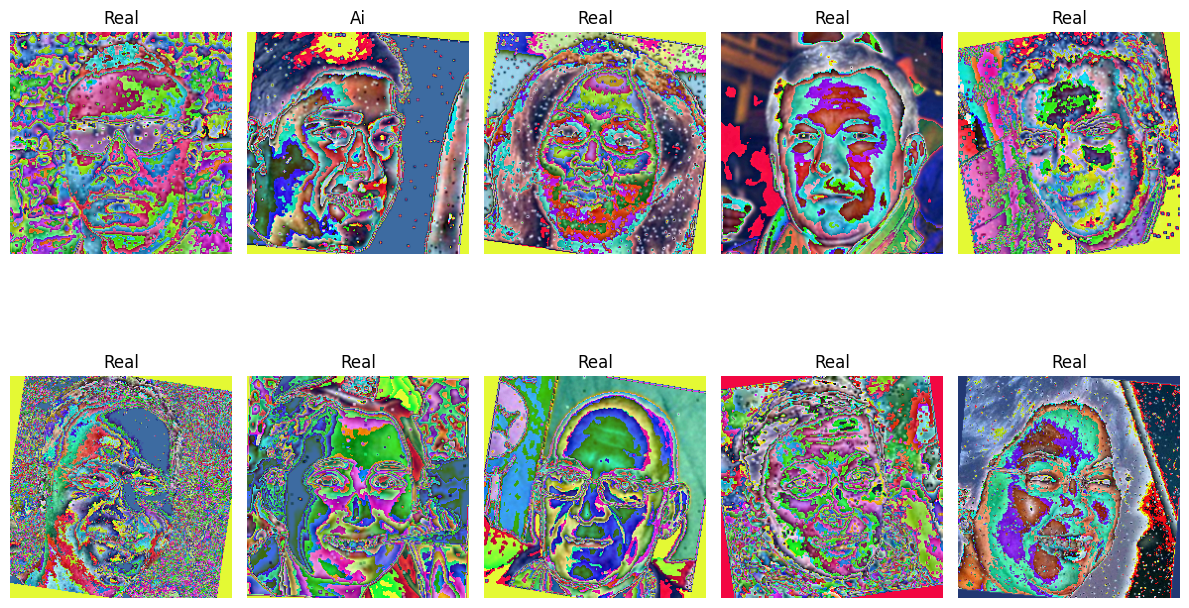

In [11]:
to_pil = transforms.ToPILImage()


def show_image(img):
    image = to_pil(img)
    plt.imshow(image)
    plt.axis("off")
    
    
dataiter = iter(train_loader)
_images, _labels = next(dataiter)
plt.figure(figsize=(12, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    show_image(_images[i])
    plt.title("Real" if _labels[i].item() == 0 else "Ai")
    
plt.tight_layout()
plt.show()

# **MODEL MODULE**

In [12]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Identity()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out += self.shortcut(x)
        out = self.relu(out)
        return out


class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.layer1 = nn.Sequential(
            ResBlock(32, 32),
            ResBlock(32, 32)
        )

        self.layer2 = nn.Sequential(
            ResBlock(32, 64, stride=2),
            ResBlock(64, 64)
        )

        self.layer3 = nn.Sequential(
            ResBlock(64, 128, stride=2),
            ResBlock(128, 128)
        )

        self.layer4 = nn.Sequential(
            ResBlock(128, 192, stride=2),
            ResBlock(192, 192)
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Linear(192, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )

    def forward(self, x):

        x = self.stem(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.pool(x)
        x = torch.flatten(x, 1)

        return self.classifier(x)

    def show_summary(self):
        summary(self, input_size=(3, 224, 224))

# **MODEL**

In [13]:
MODEL = Model().to(DEVICE)
OPTIMIZER = optim.Adam(
    MODEL.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    OPTIMIZER,
    mode="max",
    factor=0.3,
    patience=2
)
MODEL

Model(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): ResBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (shortcut): Identity()
    )
    (1): ResBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stat

In [14]:
MODEL.show_summary()

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]           4,704
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              ReLU-3         [-1, 32, 112, 112]               0
         MaxPool2d-4           [-1, 32, 56, 56]               0
            Conv2d-5           [-1, 32, 56, 56]           9,216
       BatchNorm2d-6           [-1, 32, 56, 56]              64
              ReLU-7           [-1, 32, 56, 56]               0
            Conv2d-8           [-1, 32, 56, 56]           9,216
       BatchNorm2d-9           [-1, 32, 56, 56]              64
         Identity-10           [-1, 32, 56, 56]               0
             ReLU-11           [-1, 32, 56, 56]               0
         ResBlock-12           [-1, 32, 56, 56]               0
           Conv2d-13           [-1, 32, 56, 56]           9,216
      BatchNorm2d-14           [-1, 32,

In [15]:
def show_losses(
        train_losses,
        val_losses,
        val_F1Scores
):
    clear_output()

    plt.figure(figsize=(12, 4))
    plt.plot(val_F1Scores, label="Val F1-Score")
    plt.xlabel("Epoch")
    plt.ylabel("F1-Score")
    plt.legend()
    plt.title("F1-Score curve")

    plt.subplot(1, 2, 2)
    plt.plot(train_losses, label="Train loss")
    plt.plot(val_losses, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss curves")

    plt.tight_layout()
    plt.show()

# **TRAIN MODULE**

In [16]:
def train(model, loader, optimizer):
    model.train()
    total_loss = 0
    progress_bar = tqdm(loader)
    for image, labels in progress_bar:
        image, labels = image.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
        outputs = model(image)
        
        loss = criterion(outputs, labels.float())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    
    return avg_loss


@torch.inference_mode()  # torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    
    metric_F1 = F1Score(task="binary")
    metric_F1.to(DEVICE)
    
    for image, labels in tqdm(loader):
        image, labels = image.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
        outputs = model(image)
        loss = criterion(outputs, labels.float())
        
        total_loss += loss.item()
        predictions = (outputs > 0).int()
        metric_F1.update(predictions, labels.int())
        
    avg_loss = total_loss / len(loader)
    F1_score = metric_F1.compute()
    
    return avg_loss, F1_score

# **RUN_TRAINING MODULE**

In [17]:
def run(
        model,
        _train_loader,
        _val_loader,
        optimizer,
        epochs: int = 30
):
    train_losses = []
    val_losses = []
    val_F1Scores = []

    for epoch in range(epochs):
        train_loss = train(
            model,
            _train_loader,
            optimizer
        )
        val_loss, val_F1 = evaluate(
            model,
            _val_loader
        )
        scheduler.step(val_F1)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_F1Scores.append(val_F1)
        
        show_losses(
            train_losses=train_losses,
            val_losses=val_losses,
            val_F1Scores=val_F1Scores
        )
        print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1-Score: {val_F1:.4f}")
        
    return {
        "train_losses": train_losses,
        "val_losses_hist": val_losses_hist,
        "val_F1Scores": val_F1Scores
    }

# **TRAINING**

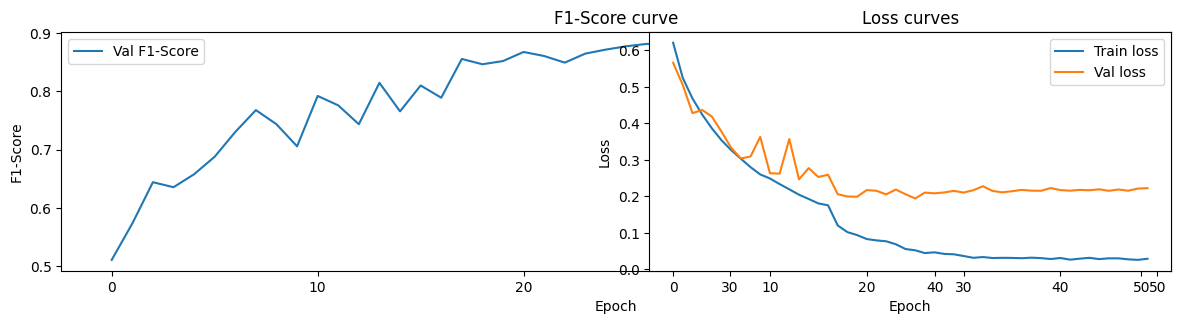

Epoch 50/50 | Train Loss: 0.0293 | Val Loss: 0.2225 | Val F1-Score: 0.8818


NameError: name 'val_losses_hist' is not defined

In [18]:
history_data = run(
    model=MODEL,
    _train_loader=train_loader,
    _val_loader=val_loader,
    optimizer=OPTIMIZER,
    epochs=200
)

# **SAVING MODEL WEIGHTS**

In [79]:
torch.save(MODEL.state_dict(), MODEL_WEIGHTS_PATH)

# **LOADING MODEL WEIGHTS**

In [80]:
MODEL.load_state_dict(torch.load(MODEL_WEIGHTS_PATH))

<All keys matched successfully>

# **TEST_DATASET MODULE**

In [81]:
all_test_data = load_all_data(
    root_dir=TEST_IMAGES_DIR
)

test_dataset = CustomDataset(
    data=all_test_data,
    _transform=base_transform
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

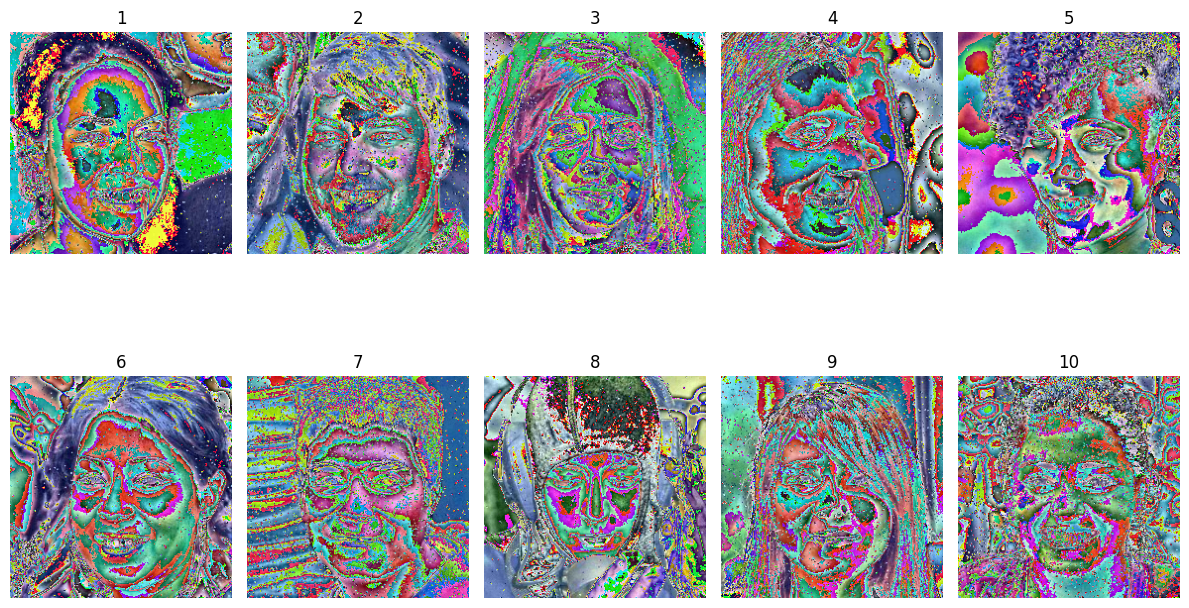

In [82]:
to_pil = transforms.ToPILImage()


def show_image(img):
    image = to_pil(img)
    plt.imshow(image)
    plt.axis("off")
    
    
dataiter = iter(test_loader)
_images, _labels = next(dataiter)
plt.figure(figsize=(12, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    show_image(_images[i])
    plt.title(_labels[i].item() + 1)
    
plt.tight_layout()
plt.show()

# **PREDICT MODULE**

In [83]:
@torch.inference_mode() # torch.no_grad()
def predict(model, _test_loader):
    model.eval()

    predictions = []

    for images, images_ids in _test_loader:
        images = images.to(DEVICE)

        outputs = model(images)
        probs = outputs.squeeze()

        predictions = (probs > 0.5).int().cpu().numpy()        
        for img_id, pred in zip(images_ids, predictions):
            predictions.append((img_id.item(), pred))

    return predictions

# **PREDICT**

In [84]:
y = predict(MODEL, test_loader)
df = pd.DataFrame(y, columns=["id", "label"])
df = df.sort_values("id")
df

AttributeError: 'numpy.ndarray' object has no attribute 'append'